# The aim here is to see whether having a richer Wikipedia/Wikidata profile makes a brand more likely to get mentioned by ChatGPT when asked different neutral prompts.

# Dataset Contains:
# Prompts: 303
# Brands: 2288

## 1) Importing Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import spearmanr
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns

## 2) Load data (code)

In [2]:
df = pd.read_csv("merged_output.csv", encoding="utf-8")

## 3) Quick data

In [4]:
print("Rows:", len(df), "| Prompts:", df['Prompt'].nunique(), "| Brands (rows):", df['brand_Name'].nunique())
df[['PageExists']].value_counts()

Rows: 2763 | Prompts: 303 | Brands (rows): 2288


PageExists
True          1815
False          948
dtype: int64

In [5]:
df.columns

Index(['Prompt', 'brand_Name', 'mention_type', 'Rank', 'Brand', 'PageExists',
       'PageLength', 'RefCount', 'Categories', 'InternalLinks',
       'AvgPageviews90d', 'Sitelinks', 'Statements'],
      dtype='object')

## Visualizing Data for Better Understanding

### Top 10 Most Frequent Brands:

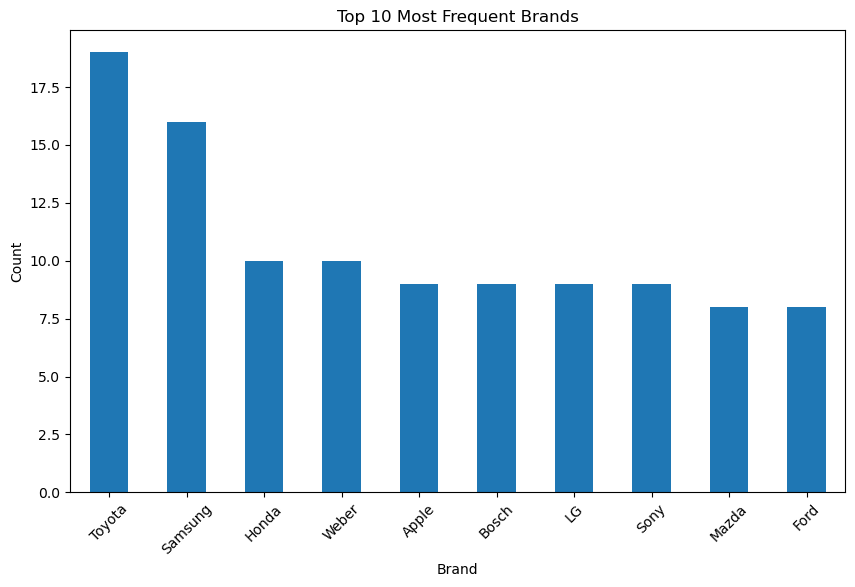

In [58]:
brand_counts = df['brand_Name'].value_counts().head(10)
plt.figure(figsize=(10,6))
brand_counts.plot(kind='bar')
plt.title("Top 10 Most Frequent Brands")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Mention Type Split (Ranked vs Bullet):

Text(0.5, 1.0, 'Count of Mentions: Ranked vs Bullet Points')

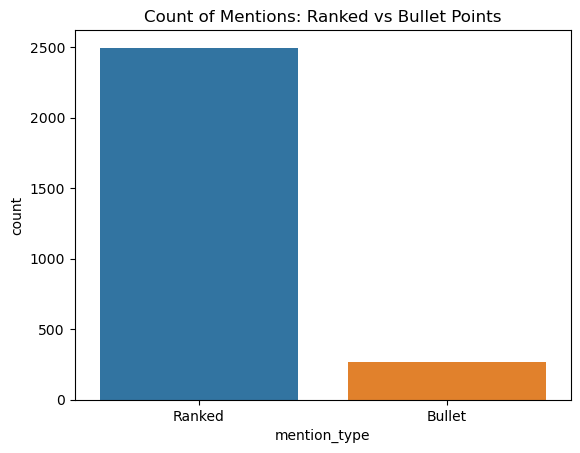

In [60]:
sns.countplot(data=df, x="mention_type")
plt.title("Count of Mentions: Ranked vs Bullet Points")

### Distribution of Brands Mentioned per Prompt:

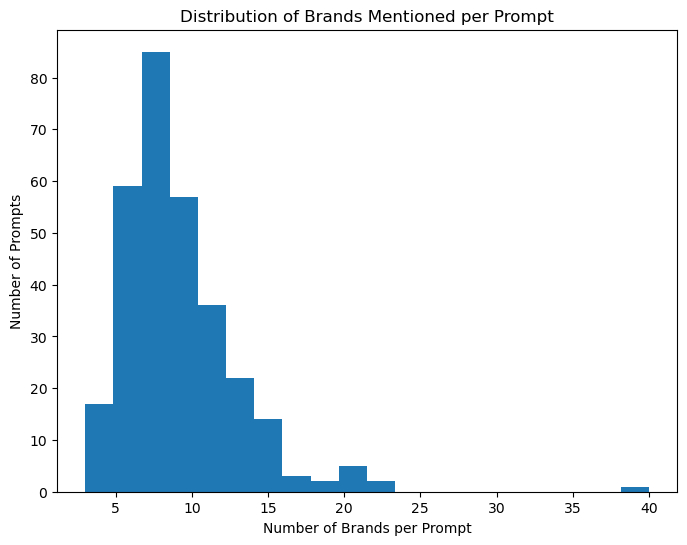

In [62]:
plt.figure(figsize=(8,6))
df.groupby("Prompt")["brand_Name"].count().plot.hist(bins=20)

plt.title("Distribution of Brands Mentioned per Prompt")
plt.xlabel("Number of Brands per Prompt")   # X-axis label
plt.ylabel("Number of Prompts")             # Y-axis label
plt.show()

### Visualizing at the Brand Level

Text(0.5, 1.0, 'Richness vs Mention Rate')

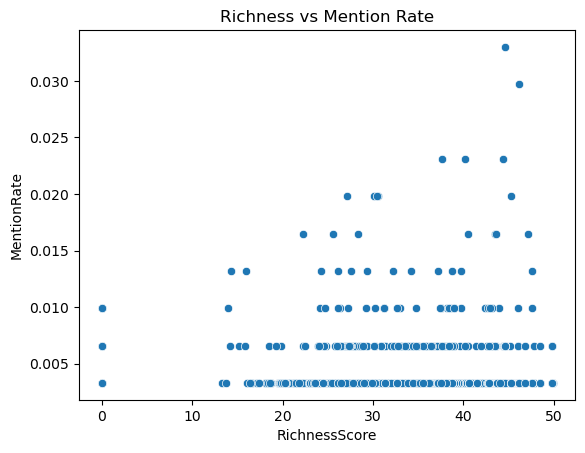

In [66]:
sns.scatterplot(data=brand_level, x="RichnessScore", y="MentionRate")
plt.title("Richness vs Mention Rate")

### Wikipedia Page Existence

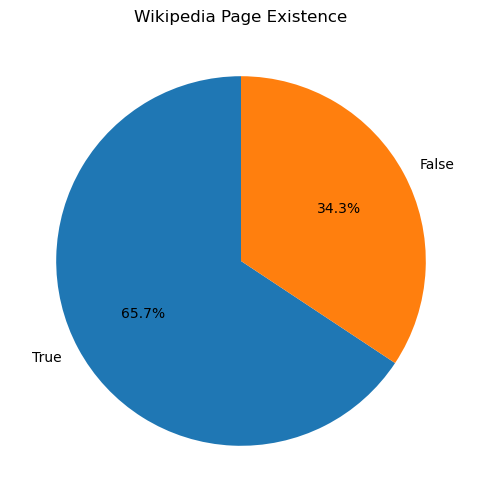

In [97]:
page_exists = df['PageExists'].value_counts()
plt.figure(figsize=(6,6))
page_exists.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Wikipedia Page Existence")
plt.ylabel("")
plt.show()

### ChatGPT Ranking Distribution by Wikipedia Page Existence

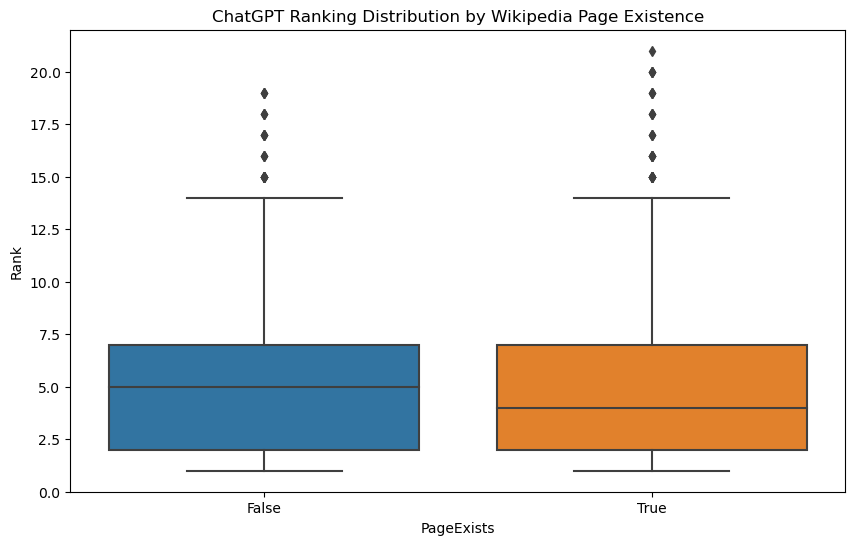

In [70]:
plt.figure(figsize=(10,6))
sns.boxplot(x="PageExists", y="Rank", data=df)
plt.title("ChatGPT Ranking Distribution by Wikipedia Page Existence")
plt.show()

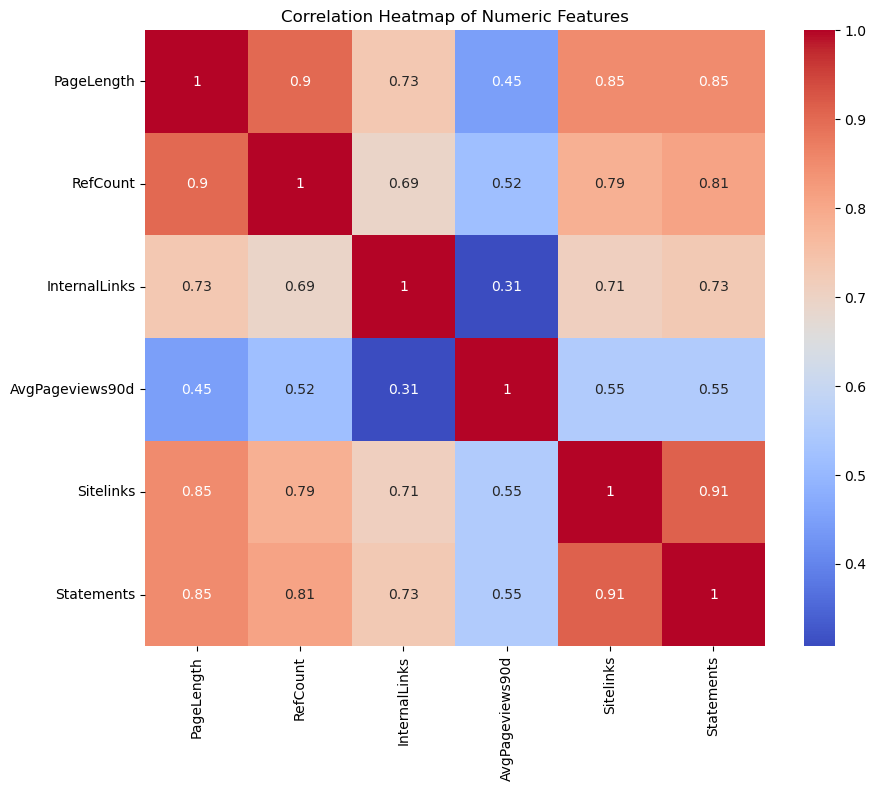

In [74]:
plt.figure(figsize=(10,8))
sns.heatmap(df[['PageLength','RefCount','InternalLinks','AvgPageviews90d','Sitelinks','Statements']].corr(), 
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# 🔎
## 1) Meaning, long Wikipedia pages tend to have more references, sitelinks, and statements.

## *AvgPageviews90d with most others (0.31–0.55)*
## 2) Page popularity (views) doesn’t necessarily mean longer or more detailed pages.

## *InternalLinks with others (~0.69–0.73)*
## 3) Pages with more internal links also tend to be longer and better referenced.

# Building RichnessScore:

## Mathematical Formula for Richness:
### log-transform each metric → sum them → get the score.

In [6]:
def add_logsum_richness(df):
    # Defining the Wikipedia-related metrics
    metrics = ["PageLength", "RefCount", "Categories", 
               "InternalLinks", "AvgPageviews90d", 
               "Sitelinks", "Statements"]
    
    # Ensure numeric conversion (non-numeric -> NaN -> 0)
    for col in metrics:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    
    # Replacing NaN with 0 (safety) and compute log(1 + value)
    log_vals = np.log1p(df[metrics].fillna(0))
    
    # Sum across all metrics = RichnessScore
    df["RichnessScore"] = log_vals.sum(axis=1)
    
    return df

# Apply function
df = add_logsum_richness(df)
print(df[["brand_Name", "RichnessScore"]].head())

  brand_Name  RichnessScore
0    Samsung      44.576985
1    SanDisk      34.651456
2    Crucial      36.832454
3    Samsung      44.576985
4      LaCie      29.144293


## Feature engineering
### Mention rate per brand across prompts-
### Top-K label  for ranking analysis-
### Average/best rank per brand-

In [14]:
TOTAL_PROMPTS = df['Prompt'].nunique()


brand_mentions = (
    df.groupby('brand_Name')
      .agg(Mentions=('Prompt', 'nunique'))
      .reset_index()
)
brand_mentions['MentionRate'] = brand_mentions['Mentions'] / TOTAL_PROMPTS


K = 3
df['TopK'] = (df['Rank'] <= K).astype(int)


brand_rank = (
    df.groupby('brand_Name')
      .agg(AvgRank=('Rank', 'mean'),
           TopK_rate=('TopK', 'mean'))
      .reset_index()
)


brand_richness = (
    df.groupby('brand_Name')
      .agg(RichnessScore=('RichnessScore', 'median'),
           PageExists=('PageExists', 'max'))
      .reset_index()
)

brand_level = (
    brand_richness
    .merge(brand_mentions, on='brand_Name', how='left')
    .merge(brand_rank, on='brand_Name', how='left')
).fillna({'MentionRate':0, 'AvgRank':np.nan, 'TopK_rate':0})

In [15]:
brand_mentions.sort_values('Mentions', ascending=False)

,brand_Name,Mentions,MentionRate
1776,Samsung,10,0.033003
2064,Toyota,9,0.029703
909,Honda,7,0.023102
112,Apple,7,0.023102
1112,LG,7,0.023102
...,...,...,...
783,Galaxy S25 Plus,1,0.003300
782,Galaxy S25,1,0.003300
781,Gainful Grass‑Fed Collagen,1,0.003300
780,Gainful,1,0.003300


In [16]:
brand_rank

,brand_Name,AvgRank,TopK_rate
0,1688.com,6.0,0.0
1,1MORE,3.0,1.0
2,1‑800 Contacts,1.0,1.0
3,2024 Panini Absolute Football Fat Pack Box,15.0,0.0
4,2024 Panini Clearly Donruss Football Hobby Box,14.0,0.0
...,...,...,...
2283,iRobot Roomba Combo j9+,6.0,0.0
2284,quip,1.5,1.0
2285,sous-vide immersion circulators,NaN,0.0
2286,thermometer,NaN,0.0


In [19]:
subset = df[["brand_Name", "RichnessScore", "Rank"]]

unique_brands = subset.drop_duplicates(subset=["brand_Name"]).reset_index(drop=True)

print(unique_brands.head())

  brand_Name  RichnessScore  Rank
0    Samsung      44.576985   1.0
1    SanDisk      34.651456   2.0
2    Crucial      36.832454   3.0
3      LaCie      29.144293   NaN
4   Kingston      34.155925   NaN


# 6) Primary tests

## 6.1 Correlation: Richness vs MentionRate (brand level)

In [27]:
# Only keep rows where PageExists is True
subset = brand_level[brand_level['PageExists'] == True]

# Spearman correlation between RichnessScore and MentionRate
rho, p = spearmanr(subset['RichnessScore'], subset['MentionRate'])

print(f"Spearman ρ (Richness vs MentionRate): {rho:.3f}, p={p:.4f}")

Spearman ρ (Richness vs MentionRate): 0.049, p=0.0633


## 👉 This means: Among brands that have a Wikipedia page, richness does not significantly predict how often they are mentioned by ChatGPT.

## 6.2 Correlation: Richness vs AvgRank (brand level)

In [28]:
# Subset only brands that actually have AvgRank values
subset = brand_level[brand_level['AvgRank'].notna()]

# Spearman correlation between RichnessScore and AvgRank
rho_r, p_r = spearmanr(subset['RichnessScore'], subset['AvgRank'])

print(f"Spearman ρ (Richness vs AvgRank): {rho_r:.3f}, p={p_r:.4f}")

Spearman ρ (Richness vs AvgRank): -0.049, p=0.0266


## 👉 Meaning: Brands with richer Wikipedia/Wikidata profiles tend to have slightly better (lower) average ranks when mentioned by ChatGPT.

## But the effect size (ρ ≈ -0.05) is so small that it’s not practically meaningful.

# Richness vs Mention Rate

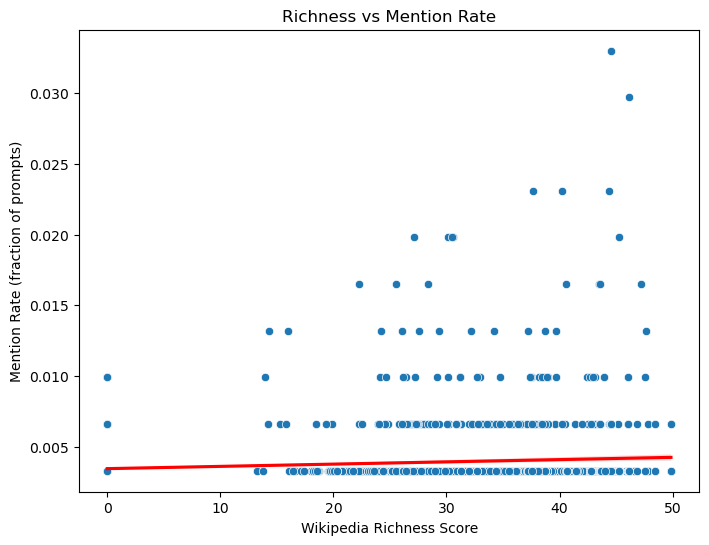

In [95]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=brand_level, x="RichnessScore", y="MentionRate")
sns.regplot(data=brand_level, x="RichnessScore", y="MentionRate", scatter=False, color="red")

plt.title("Richness vs Mention Rate")
plt.xlabel("Wikipedia Richness Score")
plt.ylabel("Mention Rate (fraction of prompts)")
plt.show()

# Richness vs Average Rank in ChatGPT Responses

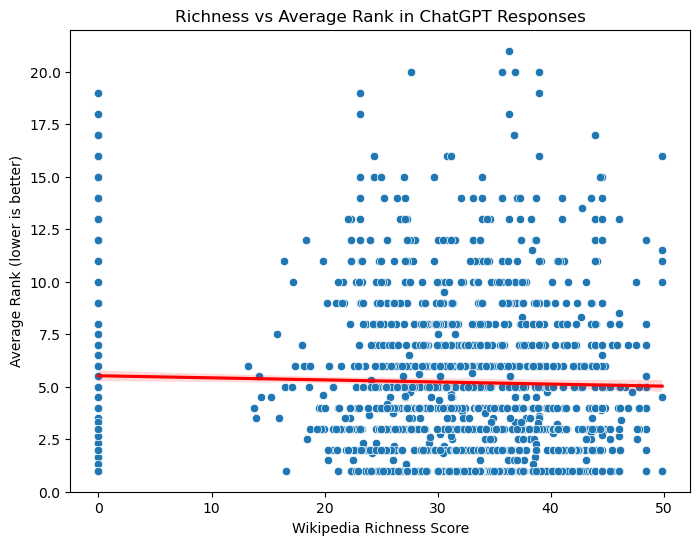

In [49]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=brand_level, x="RichnessScore", y="AvgRank")
sns.regplot(data=brand_level, x="RichnessScore", y="AvgRank", scatter=False, color="red")

plt.title("Richness vs Average Rank in ChatGPT Responses")
plt.xlabel("Wikipedia Richness Score")
plt.ylabel("Average Rank (lower is better)")
plt.show()

## Do brands with Wikipedia pages have better ranks?

In [89]:
from scipy.stats import mannwhitneyu

# Dropping NaNs before splitting
valid = brand_level.dropna(subset=['AvgRank'])

g1 = valid.loc[valid['PageExists'] == True, 'AvgRank']
g2 = valid.loc[valid['PageExists'] == False, 'AvgRank']

if len(g1) > 0 and len(g2) > 0:
    u, p = mannwhitneyu(g1, g2, alternative='two-sided')
    print(f"AvgRank (PageExists vs NoPage): U={u}, p={p:.4f}")
else:
    print("One group has no valid AvgRank values → test not possible.")

AvgRank (PageExists vs NoPage): U=473970.5, p=0.0691


### 👉 Having a Wikipedia page might slightly improve rank, but the evidence is not strong enough to confirm it at the 5% significance level.

## Do brands that appear in top ranks have richer Wikipedia profiles?

In [90]:
# RichnessScore: TopK vs Non-TopK
g1 = brand_level.loc[brand_level['TopK_rate'] > 0, 'RichnessScore']
g2 = brand_level.loc[brand_level['TopK_rate'] == 0, 'RichnessScore']

u, p = mannwhitneyu(g1, g2, alternative='two-sided')
print(f"RichnessScore (TopK vs Non-TopK): U={u}, p={p:.4f}")

RichnessScore (TopK vs Non-TopK): U=668909.0, p=0.0000


### 👉Brands with richer Wikipedia profiles are much more likely to appear in top slots.

## Does having a Wikipedia page affect whether a brand is mentioned by ChatGPT?

In [96]:
from scipy.stats import mannwhitneyu

# Only keep valid rows
valid = brand_level.dropna(subset=['MentionRate'])

# Split groups
g1 = valid.loc[valid['PageExists'] == True, 'MentionRate']
g2 = valid.loc[valid['PageExists'] == False, 'MentionRate']

# Mann–Whitney U test
if len(g1) > 0 and len(g2) > 0:
    u, p = mannwhitneyu(g1, g2, alternative='two-sided')
    print(f"MentionRate (PageExists vs NoPage): U={u:.1f}, p={p:.4f}")
else:
    print("One group has no valid MentionRate values → test not possible.")


MentionRate (PageExists vs NoPage): U=661943.0, p=0.0000


# 📝 Interpretation and Conclusion
## 1. Richness vs. Top-K Presence

### 3Test: Mann–Whitney U

### Result: U = 668909.0, p < 0.0001

### Interpretation: Brands with richer Wikipedia/Wikidata profiles are much more likely to appear in the top-ranked slots of ChatGPT responses.

# Implication: Having a strong Wikipedia/Wikidata presence can boost the chances of being highlighted prominently.

## 2. Average Rank (PageExists vs. NoPage)

### Test: Mann–Whitney U

### Result: U = 473970.5, p = 0.0691

### Interpretation: Brands with a Wikipedia page tend to rank slightly better on average, but the evidence is not statistically significant at the 5% threshold.

# Implication: Merely having a Wikipedia page may help visibility, but the effect is weak and uncertain.

## 3. Richness vs. Average Rank

### Test: Spearman correlation

### Result: ρ = -0.049, p = 0.0266

### Interpretation: There is a very weak negative correlation, meaning richer profiles are associated with slightly better (lower) average ranks.

# Implication: Although statistically significant, the effect size is so small that it has little practical importance.

## 4. Richness vs. Mention Rate

### Test: Spearman correlation

### Result: ρ = 0.049, p = 0.0633

### Interpretation: Among brands with Wikipedia pages, richness is not a significant predictor of how often they are mentioned by ChatGPT.

# Implication: Richer profiles don’t guarantee higher frequency of mentions.

# ✅ Overall Conclusion

## Strong evidence: 
## 1) Brands with richer profiles are more likely to appear in top-ranked slots.
## 2) Having a Wikipedia page strongly increases the chances of being mentioned by ChatGPT across prompts. This confirms that Wikipedia presence itself (even without richness details) matters a lot for visibility.



## Minimal evidence: Richness has almost no practical effect on how often brands are mentioned, nor on their exact rank when mentioned.


# 👉 Takeaway: Investing in richer Wikipedia/Wikidata profiles improves the chance of being placed in top slots (visibility impact). However, it does not guarantee more frequent mentions or meaningfully better rankings once a brand is included.